In [2]:
# %pip install -q -U -r "C:\Users\AYO_AYO\Desktop\Bluechip_Machine_Learning\requirements.txt"

In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [4]:
# Load iris dataset
iris = load_iris(as_frame=True)

In [5]:
df = iris.frame

In [6]:
df.shape

(150, 5)

In [7]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [8]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [10]:
# The code `print(iris.target_names)` is printing out the target class names of the Iris dataset. The `iris.target_names` attribute contains an array of the unique class labels or names that the model is trying to predict in the dataset. By using `print()`, the names of the target classes will be displayed in the output.
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [11]:
target_name = dict(enumerate(iris.target_names))

In [12]:
print(target_name)

{0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


In [13]:
df["Species"] = df["target"].map(target_name)

In [14]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [15]:
# Quick Pandas inspection
print("\n📐 Shape:", df.shape)
print("-"*50)
print("\nℹ️ Info:")
print(df.info())
print("-"*50)
print("\n📊 Describe (numeric):")
print(df.describe())


📐 Shape: (150, 6)
--------------------------------------------------

ℹ️ Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   Species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
--------------------------------------------------

📊 Describe (numeric):
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000       

### **Convert to numpy array**

In [16]:
feature_cols = iris.feature_names

X = df[feature_cols]
Y = df["target"]

In [17]:
print(type(X))
print(type(Y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [18]:
# Convert To Numpy Array
X = X.to_numpy()
Y = Y.to_numpy()

In [19]:
# NumPy stats (column-wise): mean, std
col_means = X.mean(axis=0)
col_stds = X.std(axis=0, ddof=0)  # population std (ddof=0)
print("\n🧮 NumPy column means:", col_means)
print("🧮 NumPy column stds :", col_stds)


🧮 NumPy column means: [5.84333333 3.05733333 3.758      1.19933333]
🧮 NumPy column stds : [0.82530129 0.43441097 1.75940407 0.75969263]


In [20]:
# Find missing values
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
Species              0
dtype: int64


In [21]:
df.groupby("Species")[feature_cols].mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
Species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


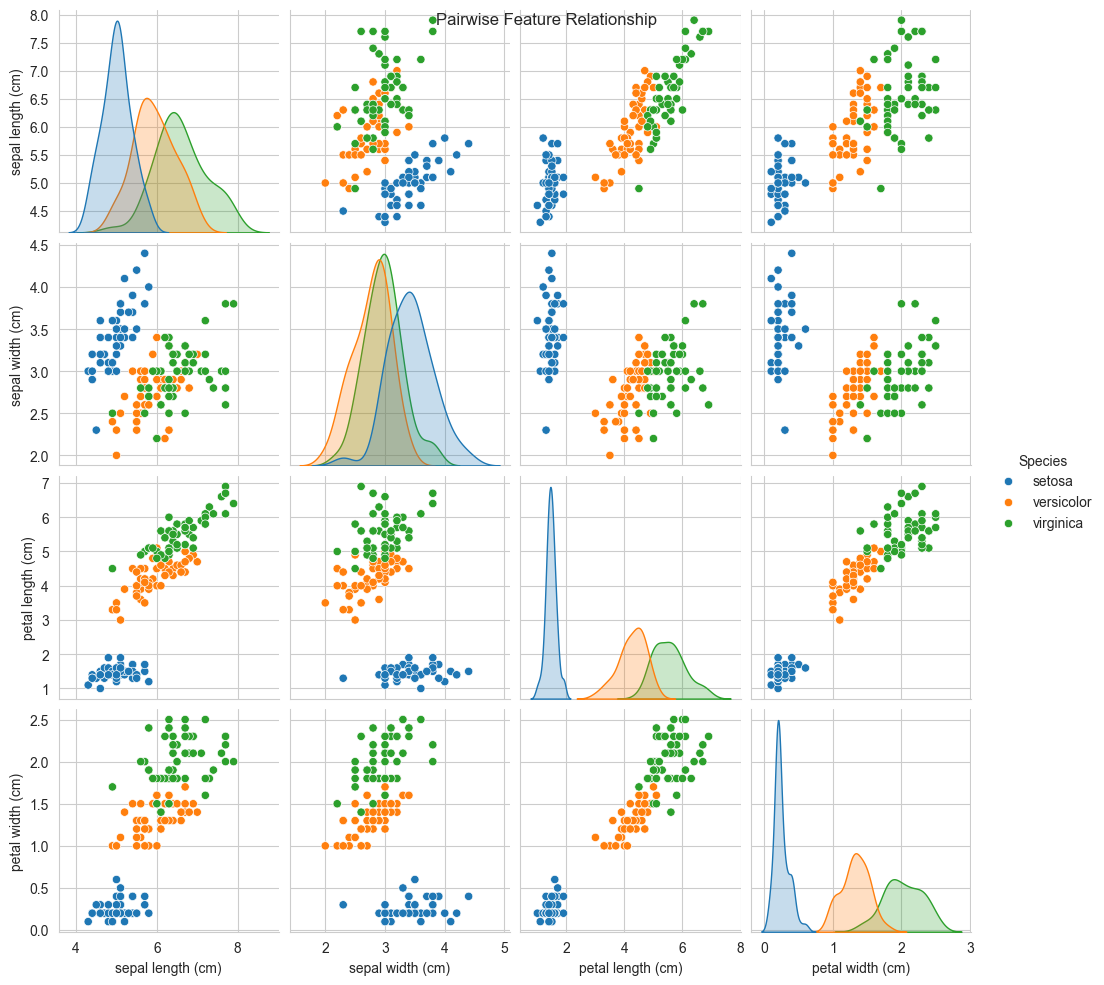

In [22]:
# Pair Plot With Seaborn

sns.set_style("whitegrid")

sns.pairplot(df[feature_cols + ["Species"]], hue="Species", diag_kind="kde")
plt.suptitle("Pairwise Feature Relationship")
plt.show()

In [23]:
# df.columns = df.columns.str.replace(" ", "_")

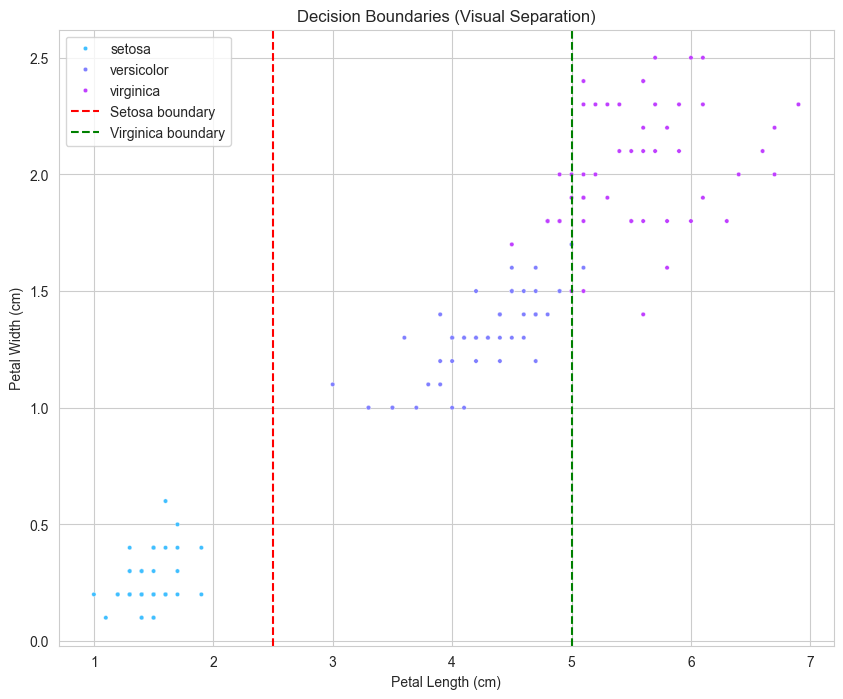

In [24]:
# Visualize the clusters properly for petal length and petal width

plt.figure(figsize=(10, 8))

sns.scatterplot(
    x="petal length (cm)",
    y="petal width (cm)",
    s=10,
    data=df,
    palette="cool",
    hue="Species"
)

# Decision boundary lines
plt.axvline(x=2.5, color='red', linestyle='--', label='Setosa boundary')
plt.axvline(x=5.0, color='green', linestyle='--', label='Virginica boundary')

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Decision Boundaries (Visual Separation)")

plt.legend()
plt.show()

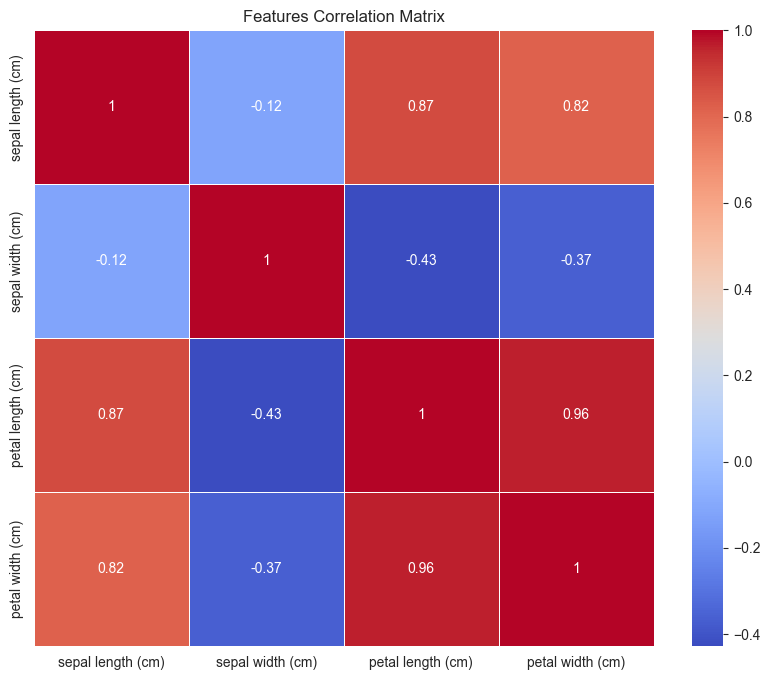

In [25]:
# Correlation Heatmap, ignoring the target colum

corr = df[feature_cols].corr(numeric_only = True)
# corr = df[["petal length (cm)", "petal width (cm)"]].corr(numeric_only = True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot = True, cmap="coolwarm", linewidths=.5)
plt.title("Features Correlation Matrix")
plt.show()

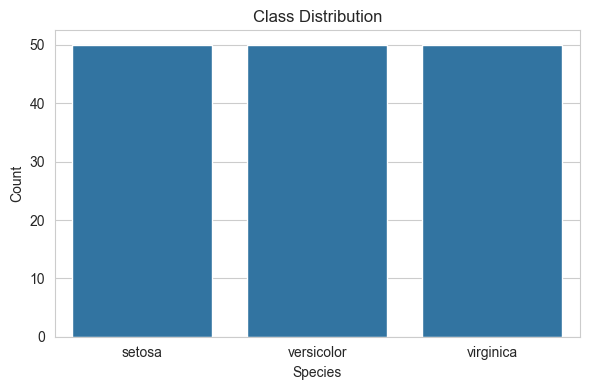

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x="Species", data=df)
plt.title("Class Distribution")
plt.xlabel("Species")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### **VISUAL: HIGH MULTICOLINEARITY AND NO MULTICOLINEARITY**

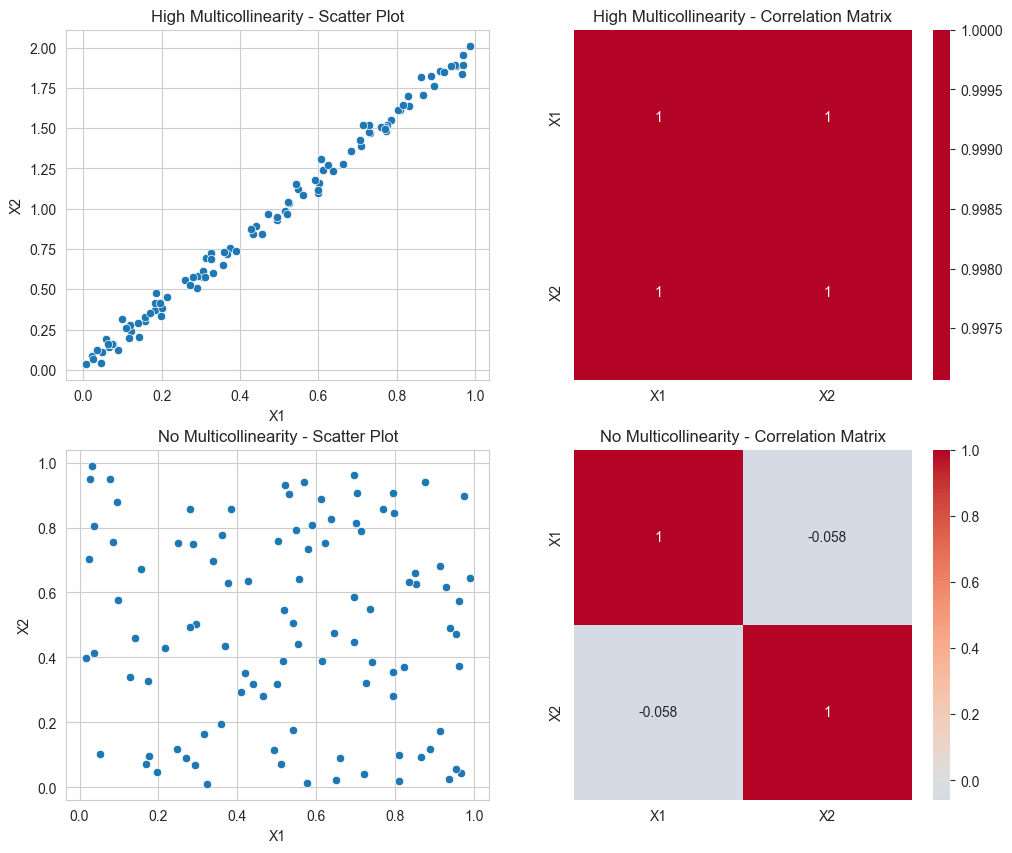

In [27]:
# Set seed for reproducibility
np.random.seed(42)

# Dataset 1: High multicollinearity
X1_high = np.random.rand(100)
X2_high = 2 * X1_high + np.random.normal(0, 0.05, 100)  # almost perfect linear relationship
df_high = pd.DataFrame({'X1': X1_high, 'X2': X2_high})

# Dataset 2: No multicollinearity
X1_no = np.random.rand(100)
X2_no = np.random.rand(100)  # independent random values
df_no = pd.DataFrame({'X1': X1_no, 'X2': X2_no})

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Scatter plots
sns.scatterplot(x='X1', y='X2', data=df_high, ax=axes[0, 0])
axes[0, 0].set_title('High Multicollinearity - Scatter Plot')
sns.scatterplot(x='X1', y='X2', data=df_no, ax=axes[1, 0])
axes[1, 0].set_title('No Multicollinearity - Scatter Plot')

# Correlation heatmaps
sns.heatmap(df_high.corr(), annot=True, cmap='coolwarm', center=0, ax=axes[0, 1])
axes[0, 1].set_title('High Multicollinearity - Correlation Matrix')
sns.heatmap(df_no.corr(), annot=True, cmap='coolwarm', center=0, ax=axes[1, 1])
axes[1, 1].set_title('No Multicollinearity - Correlation Matrix')

# plt.tight_layout()
plt.show()